# 🏭 Chapter 3: PLC Data Exploration
*Goal: Understand the raw PLC sensor data before merging with defect labels.*

---
**Sections:**
1. Load Data
2. Data Overview
3. Missing Data Analysis
4. Sensor Distributions
5. Stuck / Constant Sensors
6. Sensor Behaviour Along Coil Length
7. Sensor Correlations
8. Process Stability
9. Merge Readiness Check
10. Chapter Summary


## ⚙️ Imports & Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown  # ← add this line
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded')


✅ Libraries loaded


---
## 📂 1. Load PLC Data

In [7]:
# *** UPDATE THIS PATH TO YOUR FILE ***
PLC_PATH = 'C:/Users/IIsra/ML-Project/data/raw/RC_PRODUCTION_clean.csv'

try:
    plc_df = pd.read_csv(PLC_PATH)
    print(f'✅ Loaded: {plc_df.shape[0]:,} rows × {plc_df.shape[1]} columns')
except FileNotFoundError:
    print(f'❌ File not found at: {PLC_PATH}')
    print('   Please update PLC_PATH above.')
    plc_df = None


✅ Loaded: 299,384 rows × 110 columns


---
## 📊 2. Data Overview
First look at columns, data types, and readings per coil.

In [8]:
if plc_df is not None:
    print(f'Shape : {plc_df.shape}')
    print(f'Rows  : {plc_df.shape[0]:,}')
    print(f'Cols  : {plc_df.shape[1]}')
    print('\n📋 Column names, types and sample values:')
    dtype_df = pd.DataFrame({
        'Column'  : plc_df.columns,
        'Dtype'   : plc_df.dtypes.values,
        'Non-Null': plc_df.notnull().sum().values,
        'Sample'  : [plc_df[c].dropna().iloc[0] if plc_df[c].notnull().any() else 'N/A'
                     for c in plc_df.columns]
    })
    display(dtype_df)


Shape : (299384, 110)
Rows  : 299,384
Cols  : 110

📋 Column names, types and sample values:


,Column,Dtype,Non-Null,Sample
0,COIL,int64,299384,240627
1,DATE,str,299384,2019-03-15
2,MT,float64,299384,0.0
3,TIME_START_PROCESS,str,299384,14:25:23.060
4,SPEED_PROCESS,float64,299384,16.934625
...,...,...,...,...
105,FILL_FORZA,float64,270904,208.461938
106,FILL_TIRO,float64,270904,1258.678125
107,FILL_ALL,float64,270904,0.060291
108,FILL_BENDING_POS,float64,270904,0.258934


In [16]:
if plc_df is not None:
    # Identify sensor columns = all numeric columns except the key ones
    exclude_cols = [COIL_COL, POS_COL, DATE_COL, 'TIME_START_PROCESS']
    sensor_cols  = [c for c in plc_df.select_dtypes(include=np.number).columns
                    if c not in exclude_cols]

    print(f"✅ Key columns   : COIL={COIL_COL}, Position={POS_COL}, Date={DATE_COL}")
    print(f"📡 Sensor columns: {len(sensor_cols)} found")
    print(sensor_cols)
   

✅ Key columns   : COIL=COIL, Position=MT, Date=DATE
📡 Sensor columns: 106 found
['SPEED_PROCESS', 'TEMP_Z1', 'TEMP_Z2', 'TEMP_Z3', 'TEMP_Z4', 'TEMP_Z5', 'TEMP_Z6', 'PYRO_1_PRECHMBR', 'PYRO_2_FRST_3_ZONE', 'PYRO_3_LST_3_ZONE', 'LS_OVEN', 'LASER_FRN_1', 'LASER_FRN_2', 'LASER_FRN_3', 'LASER_FRN_4', 'LASER_FRN_5', 'LASER_FRN_6', 'LASER_FRN_7', 'LASER_FRN_8', 'LASER_FRN_9', 'AIR_CH4_1', 'AIR_CH4_2', 'AIR_CH4_3', 'AIR_CH4_4', 'AIR_CH4_5', 'AIR_CH4_6', 'AIR_Z1_1', 'AIR_Z1_2', 'AIR_Z2_1', 'AIR_Z2_2', 'AIR_Z3_1', 'AIR_Z3_2', 'AIR_Z4_1', 'AIR_Z4_2', 'AIR_Z5_1', 'AIR_Z5_2', 'AIR_Z6_1', 'AIR_Z6_2', 'GAS_Z1_1', 'GAS_Z1_2', 'GAS_Z2_1', 'GAS_Z2_2', 'GAS_Z3_1', 'GAS_Z3_2', 'GAS_Z4_1', 'GAS_Z4_2', 'GAS_Z5_1', 'GAS_Z5_2', 'GAS_Z6_1', 'GAS_Z6_2', 'FRN_PHF_PRESSURE', 'FRN_FURNACE_PRESSURE', 'TIRO_FORNO', 'PRES_ZONA1_MEASURED', 'PRES_ZONA1_SET', 'PRES_ZONA2_MEASURED', 'PRES_ZONA2_SET', 'PRES_ZONA3_MEASURED', 'PRES_ZONA3_SET', 'EXT_1', 'EXT_2', 'VENT_1', 'VENT_2', 'VENT_3', 'VENT_4', 'VENT_5', 'COOL_1A', 'C

In [17]:
 print(plc_df.columns[plc_df.columns.duplicated(keep=False)].tolist())

[]


In [19]:
# ============================================================
# FULL SENSOR DICTIONARY — rebuilt from actual data
# ============================================================

sensor_groups = {

    # --- Process speed ---
    'speed': [
        'SPEED_PROCESS',   # Overall line speed
        'SPEED_FILL',      # Finishing section speed
    ],

    # --- Furnace temperatures (6 zones) ---
    'furnace_temp': [
        'TEMP_Z1', 'TEMP_Z2', 'TEMP_Z3',
        'TEMP_Z4', 'TEMP_Z5', 'TEMP_Z6',
    ],

    # --- Furnace pyrometers ---
    'furnace_pyro': [
        'PYRO_1_PRECHMBR',       # Pre-chamber
        'PYRO_2_FRST_3_ZONE',    # First 3 zones
        'PYRO_3_LST_3_ZONE',     # Last 3 zones
    ],

    # --- Furnace laser (strip position/length per zone) ---
    'furnace_laser': [f'LASER_FRN_{i}' for i in range(1, 10)],  # 9 sensors

    # --- Furnace air/gas ratio per zone (combustion control) ---
    'furnace_air': [
        'AIR_CH4_1', 'AIR_CH4_2', 'AIR_CH4_3',
        'AIR_CH4_4', 'AIR_CH4_5', 'AIR_CH4_6',
        'AIR_Z1_1', 'AIR_Z1_2',
        'AIR_Z2_1', 'AIR_Z2_2',
        'AIR_Z3_1', 'AIR_Z3_2',
        'AIR_Z4_1', 'AIR_Z4_2',
        'AIR_Z5_1', 'AIR_Z5_2',
        'AIR_Z6_1', 'AIR_Z6_2',
    ],
    'furnace_gas': [
        'GAS_Z1_1', 'GAS_Z1_2',
        'GAS_Z2_1', 'GAS_Z2_2',
        'GAS_Z3_1', 'GAS_Z3_2',
        'GAS_Z4_1', 'GAS_Z4_2',
        'GAS_Z5_1', 'GAS_Z5_2',
        'GAS_Z6_1', 'GAS_Z6_2',
    ],

    # --- Furnace pressures ---
    'furnace_pressure': [
        'FRN_PHF_PRESSURE',
        'FRN_FURNACE_PRESSURE',
        'TIRO_FORNO',           # Furnace draft
        'PRES_ZONA1_MEASURED', 'PRES_ZONA1_SET',
        'PRES_ZONA2_MEASURED', 'PRES_ZONA2_SET',
        'PRES_ZONA3_MEASURED', 'PRES_ZONA3_SET',
    ],

    # --- Furnace misc ---
    'furnace_misc': [
        'LS_OVEN',    # Furnace line speed setpoint
        'EXT_1', 'EXT_2',                          # Extractors
        'VENT_1', 'VENT_2', 'VENT_3', 'VENT_4', 'VENT_5',  # Ventilation
    ],

    # --- Cooling section ---
    'cooling': [
        'COOL_1A', 'COOL_1B',
        'COOL_2A', 'COOL_2B',
        'COOL_3',
        'LS_COOLING',   # Cooling line speed
    ],

    # --- Raffination lasers (strip measurements post-furnace) ---
    'raffination_laser': [f'LASER_RAFF_{i}' for i in range(1, 10)],  # 9 sensors

    # --- Raffination water ---
    'raffination_water': [
        'N_RAMPE_H2O',    # Number of active water ramps
        'TOUT_RAFF_H2O',  # Water outlet temperature
    ],

    # --- Electrolytic section ---
    'electrolytic': [
        'ELET_TEMP',       # Bath temperature
        'ELET_H2SO4',      # Sulphuric acid concentration
        'ELET_FE2',        # Iron (Fe2+) concentration
        'ELET_CORRENTE',   # Current
    ],

    # --- Pickling / descaling chemistry ---
    'descaling_chemistry': [
        'DEC_FETOT',    # Total iron
        'DEC_TEMP',     # Bath temperature
        'DEC_H2SO4',    # Sulphuric acid
        'DEC_HF',       # Hydrofluoric acid
        'DEC_FE2',      # Iron Fe2+
        'DEC_FE3',      # Iron Fe3+
    ],

    # --- Squeezer rolls (SPZ) ---
    'squeezers': [
        'SPZ2_R1', 'SPZ2_R2', 'SPZ2_R3', 'SPZ2_R4',  # Section 2
        'SPZ1_R1_ASS', 'SPZ1_R2_ASS',                  # Section 1
    ],

    # --- Pickling tension & speed ---
    'pickling_process': [
        'TIRO_DECAP',   # Pickling tension
    ],

    # --- Finishing section ---
    'finishing': [
        'FILL_FORZA',   # Finishing force
        'FILL_TIRO',    # Finishing tension
        'FILL_ALL',     # Finishing alignment
        'FILL_BENDING_POS', 'FILL_BENDING_NEG',
    ],
}

# ── Verify against actual sensor_cols ────────────────────────────────────────
all_sensors    = [col for group in sensor_groups.values() for col in group]
col_to_group   = {col: grp for grp, cols in sensor_groups.items() for col in cols}

missing_from_dict = [c for c in sensor_cols if c not in all_sensors]
extra_in_dict     = [c for c in all_sensors  if c not in sensor_cols]

print(f"📡 Sensors in data       : {len(sensor_cols)}")
print(f"📖 Sensors in dictionary : {len(all_sensors)}")
print(f"⚠️  In data but not dict : {missing_from_dict}")
print(f"⚠️  In dict but not data : {extra_in_dict}")

if not missing_from_dict and not extra_in_dict:
    print("\n✅ Dictionary matches data perfectly!")

📡 Sensors in data       : 106
📖 Sensors in dictionary : 106
⚠️  In data but not dict : []
⚠️  In dict but not data : []

✅ Dictionary matches data perfectly!


In [15]:
# *** CONFIRMED — paste this into your notebook ***
COIL_COL = 'COIL'
POS_COL  = 'MT'
DATE_COL = 'DATE'

print(f"COIL_COL = '{COIL_COL}'")
print(f"POS_COL  = '{POS_COL}'")
print(f"DATE_COL = '{DATE_COL}'")


COIL_COL = 'COIL'
POS_COL  = 'MT'
DATE_COL = 'DATE'


Unique coils             : 1,261
Rows per coil — mean     : 237.4
Rows per coil — min/max  : 2 / 1107
Coils with only 1 row    : 0

Date range : 2019-03-01 00:00:00 → 2019-05-16 00:00:00


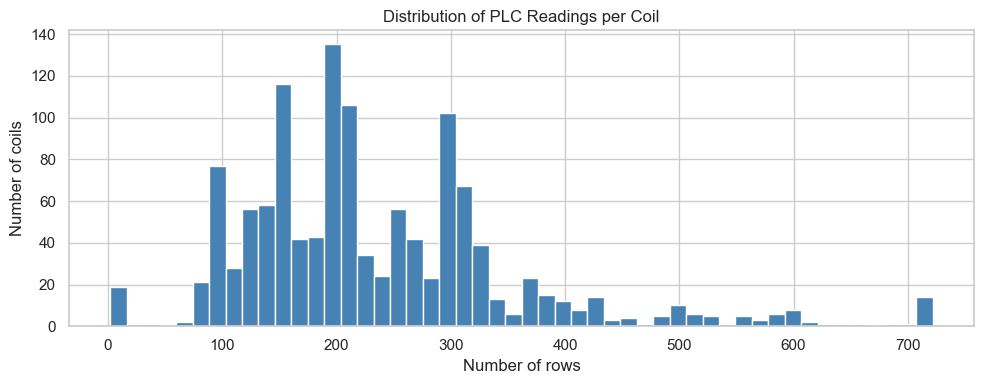

In [20]:
if plc_df is not None and COIL_COL in plc_df.columns:
    n_coils       = plc_df[COIL_COL].nunique()
    rows_per_coil = plc_df.groupby(COIL_COL).size()
    print(f'Unique coils             : {n_coils:,}')
    print(f'Rows per coil — mean     : {rows_per_coil.mean():.1f}')
    print(f'Rows per coil — min/max  : {rows_per_coil.min()} / {rows_per_coil.max()}')
    print(f'Coils with only 1 row    : {(rows_per_coil == 1).sum()}')
    if DATE_COL and DATE_COL in plc_df.columns:
        plc_df[DATE_COL] = pd.to_datetime(plc_df[DATE_COL], errors='coerce')
        print(f'\nDate range : {plc_df[DATE_COL].min()} → {plc_df[DATE_COL].max()}')
    fig, ax = plt.subplots(figsize=(10, 4))
    rows_per_coil.clip(upper=rows_per_coil.quantile(0.99)).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Distribution of PLC Readings per Coil')
    ax.set_xlabel('Number of rows')
    ax.set_ylabel('Number of coils')
    plt.tight_layout()
    plt.show()


In [21]:
# Investigate coils with very few rows
short_coils = rows_per_coil[rows_per_coil <= 10].sort_values()
print(f"Coils with ≤10 rows: {len(short_coils)}")
print(short_coils)

# Look at what those coils actually contain
if len(short_coils) > 0:
    display(plc_df[plc_df[COIL_COL].isin(short_coils.index)])



Coils with ≤10 rows: 19
COIL
422319    2
418349    2
418315    2
408915    2
394828    2
395726    2
396323    2
400039    2
400148    2
404717    2
406938    2
407825    3
389937    3
418848    3
394719    3
394340    3
393524    3
406920    3
403272    3
dtype: int64


,COIL,DATE,MT,TIME_START_PROCESS,SPEED_PROCESS,TEMP_Z1,TEMP_Z2,TEMP_Z3,TEMP_Z4,TEMP_Z5,...,SPZ2_R4,SPZ1_R1_ASS,SPZ1_R2_ASS,TIRO_DECAP,SPEED_FILL,FILL_FORZA,FILL_TIRO,FILL_ALL,FILL_BENDING_POS,FILL_BENDING_NEG
28969,389937,2019-03-04,147.0,19:24:45.630,34.780797,1235.953636,1259.674773,1270.744773,1259.907955,1260.408068,...,530.267484,23.625000,25.875000,2752.159219,61.174056,676.054644,4080.715962,0.699131,0.162015,0.134980
28970,389937,2019-03-04,154.0,19:25:00.630,34.781737,1236.017250,1259.561250,1270.674000,1259.724375,1260.222750,...,530.195062,23.625000,25.875000,2752.205625,61.174237,700.687929,4077.781071,0.698434,0.162027,0.134975
28971,389937,2019-03-04,161.0,19:25:00.630,34.784887,1236.033000,1259.325000,1270.737000,1259.685000,1260.128250,...,530.012531,23.625000,25.873313,2752.280156,61.160850,705.220554,4073.146071,0.698703,0.162014,0.134981
59137,393524,2019-03-12,189.0,21:15:11.180,31.426554,1271.600357,1271.267679,1275.843214,1281.918214,1316.341607,...,530.317768,20.250000,21.375000,4352.964107,48.572100,1035.729000,4192.402500,0.573167,0.135007,0.215967
59138,393524,2019-03-12,196.0,21:57:26.180,31.419739,1271.677500,1271.319107,1276.711071,1283.070536,1318.281429,...,530.548714,20.250000,21.375000,4353.537857,47.191684,1036.656102,4193.805682,0.570917,0.134985,0.215972
59139,393524,2019-03-12,203.0,21:57:41.180,31.413664,1271.796429,1271.372143,1277.145000,1283.067321,1318.422857,...,530.136000,20.250000,21.375000,4353.349821,45.842456,1027.276875,4196.497500,0.568169,0.134986,0.215980
68927,394340,2019-03-15,259.0,09:19:08.330,17.954325,1271.812500,1293.525000,1304.190000,1316.722500,1333.631250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68928,394340,2019-03-16,273.0,01:00:22.520,38.154774,1272.977386,1270.472727,1278.441818,1283.148409,1317.013977,...,530.284500,16.875000,16.954862,2996.066250,65.065523,718.651275,5003.277000,0.511957,0.135004,0.188963
68929,394340,2019-03-16,280.0,01:00:22.520,38.150192,1273.149205,1270.601591,1278.685227,1283.270114,1316.827841,...,530.070000,16.875000,16.933037,2996.347500,65.401628,720.860475,5027.605500,0.517447,0.134988,0.188962
75291,394719,2019-03-11,70.0,16:09:04.480,50.490281,1270.200938,1293.786562,1305.022500,1316.120625,1332.902813,...,530.382844,18.005747,18.055716,2548.387500,62.086002,642.898607,4180.819821,0.555173,0.135068,0.243014


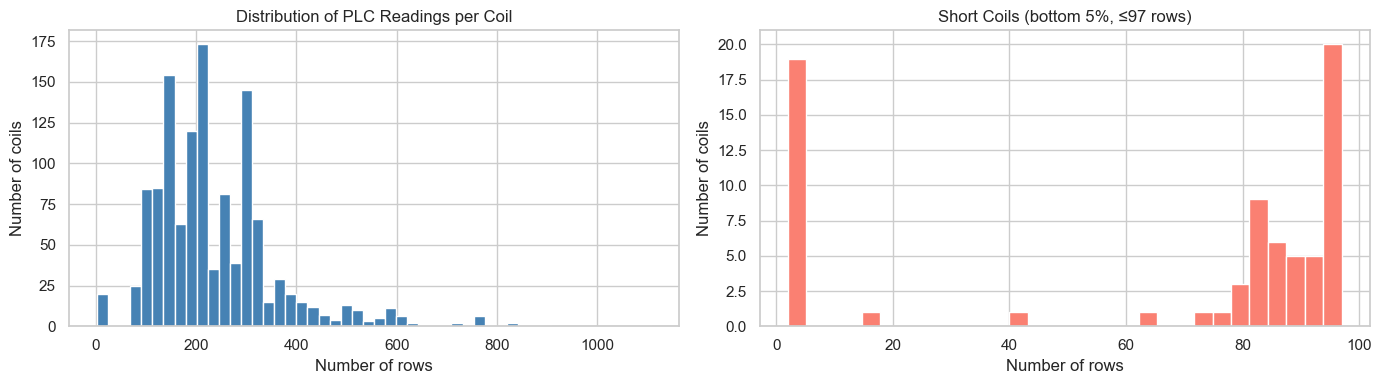


📊 Coil length summary:
  ≤ 10  rows : 19 coils
  ≤ 50  rows : 21 coils
  ≤ 100 rows : 114 coils
  > 100 rows : 1147 coils


In [22]:
# Distribution of rows per coil
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution
rows_per_coil.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of PLC Readings per Coil')
axes[0].set_xlabel('Number of rows')
axes[0].set_ylabel('Number of coils')

# Right: zoom in on short coils (bottom 5%)
cutoff = rows_per_coil.quantile(0.05)
rows_per_coil[rows_per_coil <= cutoff].hist(bins=30, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title(f'Short Coils (bottom 5%, ≤{cutoff:.0f} rows)')
axes[1].set_xlabel('Number of rows')
axes[1].set_ylabel('Number of coils')

plt.tight_layout()
plt.show()

print(f"\n📊 Coil length summary:")
print(f"  ≤ 10  rows : {(rows_per_coil <= 10).sum()} coils")
print(f"  ≤ 50  rows : {(rows_per_coil <= 50).sum()} coils")
print(f"  ≤ 100 rows : {(rows_per_coil <= 100).sum()} coils")
print(f"  > 100 rows : {(rows_per_coil > 100).sum()} coils")

In [23]:
# Flag coils with suspiciously few rows for domain expert review
SHORT_COIL_THRESHOLD = 10  # adjust after domain input

short_coil_ids = rows_per_coil[rows_per_coil <= SHORT_COIL_THRESHOLD].index.tolist()

print(f"⚠️  Coils with ≤{SHORT_COIL_THRESHOLD} rows: {len(short_coil_ids)}")
print(f"   Coil IDs: {short_coil_ids}")
print(f"\n💡 Recommendation: exclude from ML training until domain expert confirms")
print(f"   This affects {len(short_coil_ids) / plc_df[COIL_COL].nunique() * 100:.1f}% of all coils")

⚠️  Coils with ≤10 rows: 19
   Coil IDs: [389937, 393524, 394340, 394719, 394828, 395726, 396323, 400039, 400148, 403272, 404717, 406920, 406938, 407825, 408915, 418315, 418349, 418848, 422319]

💡 Recommendation: exclude from ML training until domain expert confirms
   This affects 1.5% of all coils


In [24]:
# ============================================================
# FINDING 1: Short coils — store for later filtering
# ============================================================

SHORT_COIL_THRESHOLD = 10
short_coil_ids = rows_per_coil[rows_per_coil <= SHORT_COIL_THRESHOLD].index.tolist()

print("📋 Finding 1: Short Coils")
print(f"  Count     : {len(short_coil_ids)} coils ({len(short_coil_ids)/plc_df[COIL_COL].nunique()*100:.1f}%)")
print(f"  Threshold : ≤{SHORT_COIL_THRESHOLD} rows")
print(f"  Action    : Flagged — exclude from ML training pending domain review")
print(f"  IDs       : {short_coil_ids}")

# Store as a set for easy filtering later
SHORT_COILS = set(short_coil_ids)

📋 Finding 1: Short Coils
  Count     : 19 coils (1.5%)
  Threshold : ≤10 rows
  Action    : Flagged — exclude from ML training pending domain review
  IDs       : [389937, 393524, 394340, 394719, 394828, 395726, 396323, 400039, 400148, 403272, 404717, 406920, 406938, 407825, 408915, 418315, 418349, 418848, 422319]


---
## 🕳️ 3. Missing Data Analysis
Which sensors have missing values, and do the same rows tend to be missing together?

Columns with NO missing data : 57
Columns WITH missing data    : 53
Overall missing rate         : 2.76%


,Missing Count,Missing %,Group
FILL_BENDING_NEG,28480,9.51,finishing
FILL_BENDING_POS,28480,9.51,finishing
FILL_ALL,28480,9.51,finishing
FILL_TIRO,28480,9.51,finishing
FILL_FORZA,28480,9.51,finishing
SPEED_FILL,28480,9.51,speed
LASER_RAFF_6,15734,5.26,raffination_laser
LASER_RAFF_2,15734,5.26,raffination_laser
LASER_RAFF_3,15734,5.26,raffination_laser
LASER_RAFF_4,15734,5.26,raffination_laser


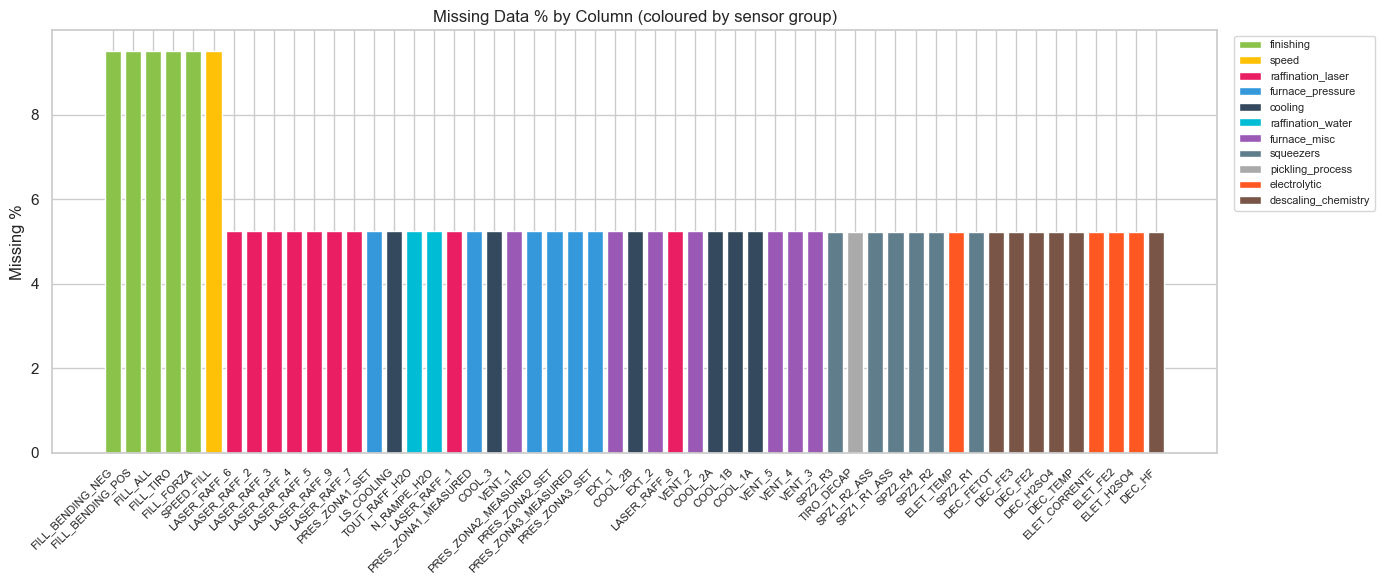

In [25]:
# ============================================================
# SECTION 3: Missing Data Analysis
# ============================================================

missing     = plc_df.isnull().sum()
missing_pct = (missing / len(plc_df)) * 100

# Only columns that have missing values
cols_missing    = missing[missing > 0].sort_values(ascending=False)
missing_pct_flt = missing_pct[missing > 0].sort_values(ascending=False)

print(f"Columns with NO missing data : {(missing == 0).sum()}")
print(f"Columns WITH missing data    : {(missing > 0).sum()}")
print(f"Overall missing rate         : {missing.sum() / plc_df.size * 100:.2f}%")

if len(cols_missing) > 0:
    # Add group label to each missing column
    summary = pd.DataFrame({
        'Missing Count': cols_missing,
        'Missing %'    : missing_pct_flt.round(2),
        'Group'        : [col_to_group.get(c, '❓ unknown') for c in cols_missing.index]
    })
    display(summary)

    # Bar chart coloured by group
    group_colors = {
        'furnace_temp'        : '#e74c3c',
        'furnace_pyro'        : '#e67e22',
        'furnace_laser'       : '#f1c40f',
        'furnace_air'         : '#2ecc71',
        'furnace_gas'         : '#1abc9c',
        'furnace_pressure'    : '#3498db',
        'furnace_misc'        : '#9b59b6',
        'cooling'             : '#34495e',
        'raffination_laser'   : '#e91e63',
        'raffination_water'   : '#00bcd4',
        'electrolytic'        : '#ff5722',
        'descaling_chemistry' : '#795548',
        'squeezers'           : '#607d8b',
        'finishing'           : '#8bc34a',
        'speed'               : '#ffc107',
    }
    colors = [group_colors.get(col_to_group.get(c, ''), '#aaaaaa') for c in cols_missing.index]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(len(cols_missing)), missing_pct_flt.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(cols_missing)))
    ax.set_xticklabels(cols_missing.index, rotation=45, ha='right', fontsize=8)
    ax.set_title('Missing Data % by Column (coloured by sensor group)')
    ax.set_ylabel('Missing %')

    # Legend
    seen = {}
    for c, col in zip(colors, cols_missing.index):
        grp = col_to_group.get(col, 'unknown')
        if grp not in seen:
            seen[grp] = c
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k) for k, v in seen.items()]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing data found!")

In [26]:
# ============================================================
# FINDING 2: Missing Data Patterns
# ============================================================

# Define the 3 patterns
pattern_A = ['FILL_BENDING_NEG', 'FILL_BENDING_POS', 'FILL_ALL',
             'FILL_TIRO', 'FILL_FORZA', 'SPEED_FILL']

pattern_B = [c for c in cols_missing.index if missing_pct[c].round(2) == 5.26]

pattern_C = [c for c in cols_missing.index if missing_pct[c].round(2) == 5.23]

# Check: are patterns B and C missing on the SAME rows?
mask_B = plc_df[pattern_B[0]].isnull()
mask_C = plc_df[pattern_C[0]].isnull()
mask_A = plc_df[pattern_A[0]].isnull()

overlap_BC = (mask_B & mask_C).sum()
only_B     = (mask_B & ~mask_C).sum()
only_C     = (~mask_B & mask_C).sum()

print("🔍 Are Pattern B and C missing on the same rows?")
print(f"  Missing in BOTH B and C : {overlap_BC:,}")
print(f"  Missing in B only       : {only_B:,}")
print(f"  Missing in C only       : {only_C:,}")

print("\n🔍 Does Pattern A overlap with B/C?")
overlap_AB = (mask_A & mask_B).sum()
only_A     = (mask_A & ~mask_B).sum()
print(f"  Missing in BOTH A and B : {overlap_AB:,}")
print(f"  Missing in A only       : {only_A:,}")

# Which coils are affected by each pattern?
coils_A = set(plc_df[mask_A][COIL_COL].unique())
coils_B = set(plc_df[mask_B][COIL_COL].unique())
coils_C = set(plc_df[mask_C][COIL_COL].unique())

print(f"\n📊 Coils affected:")
print(f"  Pattern A (finishing)   : {len(coils_A):,} coils")
print(f"  Pattern B (raffination) : {len(coils_B):,} coils")
print(f"  Pattern C (pickling)    : {len(coils_C):,} coils")
print(f"  B ∩ C (same coils)      : {len(coils_B & coils_C):,} coils")
print(f"  A ∩ B (same coils)      : {len(coils_A & coils_B):,} coils")
print(f"  All 3 overlap           : {len(coils_A & coils_B & coils_C):,} coils")

🔍 Are Pattern B and C missing on the same rows?
  Missing in BOTH B and C : 9,126
  Missing in B only       : 6,608
  Missing in C only       : 6,521

🔍 Does Pattern A overlap with B/C?
  Missing in BOTH A and B : 9,264
  Missing in A only       : 19,216

📊 Coils affected:
  Pattern A (finishing)   : 1,194 coils
  Pattern B (raffination) : 732 coils
  Pattern C (pickling)    : 1,232 coils
  B ∩ C (same coils)      : 719 coils
  A ∩ B (same coils)      : 707 coils
  All 3 overlap           : 696 coils


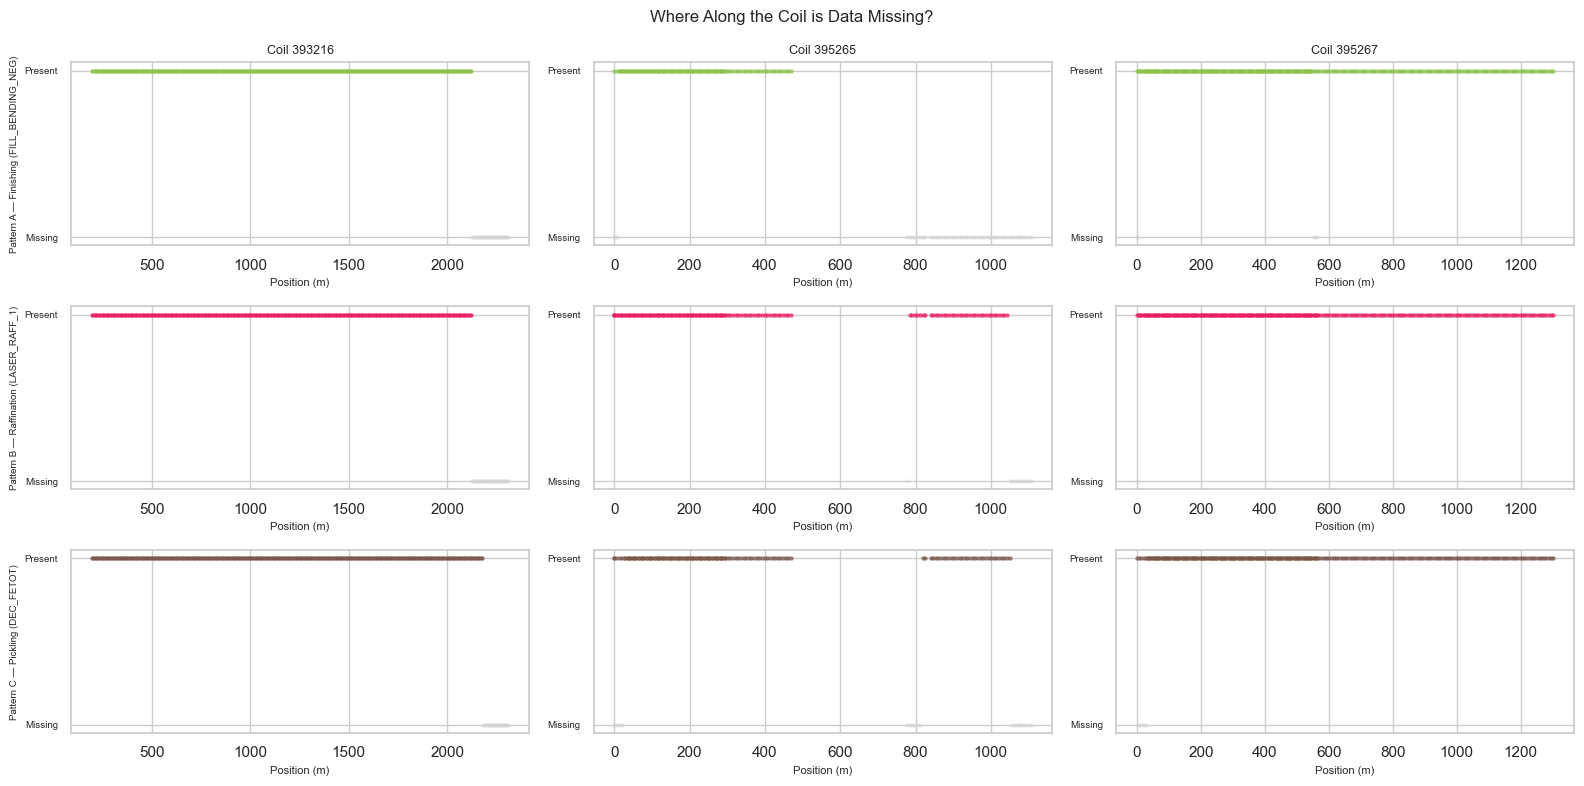

📏 Missing position analysis:

  Finishing (FILL_BENDING_NEG):
    Missing position — mean: 1528.8m, median: 1260.0m
    Present position — mean: 959.6m, median: 777.0m

  Raffination (LASER_RAFF_1):
    Missing position — mean: 1451.1m, median: 1183.0m
    Present position — mean: 989.5m, median: 798.0m

  Pickling (DEC_FETOT):
    Missing position — mean: 1410.7m, median: 1176.0m
    Present position — mean: 991.9m, median: 805.0m


In [27]:
# ============================================================
# FINDING 2b: WHERE within the coil is data missing?
# ============================================================

# Pick one representative column from each pattern
rep_A = 'FILL_BENDING_NEG'
rep_B = 'LASER_RAFF_1'
rep_C = 'DEC_FETOT'

# Sample a few coils that have missing data in all 3 patterns
sample_coils = list(coils_A & coils_B & coils_C)[:3]

fig, axes = plt.subplots(3, len(sample_coils), figsize=(16, 8))

for col_idx, coil in enumerate(sample_coils):
    coil_data = plc_df[plc_df[COIL_COL] == coil].sort_values(POS_COL)

    for row_idx, (rep, label, color) in enumerate([
        (rep_A, 'Pattern A — Finishing (FILL_BENDING_NEG)', '#8bc34a'),
        (rep_B, 'Pattern B — Raffination (LASER_RAFF_1)',   '#e91e63'),
        (rep_C, 'Pattern C — Pickling (DEC_FETOT)',         '#795548'),
    ]):
        ax = axes[row_idx, col_idx]
        present = coil_data[coil_data[rep].notnull()]
        missing = coil_data[coil_data[rep].isnull()]

        ax.scatter(present[POS_COL], [1] * len(present),
                   c=color, s=5, label='Present', alpha=0.6)
        ax.scatter(missing[POS_COL], [0] * len(missing),
                   c='lightgrey', s=5, label='Missing', alpha=0.4)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Missing', 'Present'], fontsize=7)
        ax.set_xlabel('Position (m)', fontsize=8)

        if col_idx == 0:
            ax.set_ylabel(label, fontsize=7)
        if row_idx == 0:
            ax.set_title(f'Coil {coil}', fontsize=9)

fig.suptitle('Where Along the Coil is Data Missing?', fontsize=12)
plt.tight_layout()
plt.show()

# Also check: is missing data concentrated at coil start/end?
print("📏 Missing position analysis:")
for rep, label in [(rep_A, 'Finishing'), (rep_B, 'Raffination'), (rep_C, 'Pickling')]:
    missing_pos = plc_df[plc_df[rep].isnull()][POS_COL]
    present_pos = plc_df[plc_df[rep].notnull()][POS_COL]
    print(f"\n  {label} ({rep}):")
    print(f"    Missing position — mean: {missing_pos.mean():.1f}m, median: {missing_pos.median():.1f}m")
    print(f"    Present position — mean: {present_pos.mean():.1f}m, median: {present_pos.median():.1f}m")

In [30]:
# ============================================================
# FINDING 2 — FINAL: Missing Data Summary
# ============================================================

display(Markdown("""
## 🕳️ Finding 2: Missing Data — Tail-Out Effect

### Pattern Summary
| Pattern | Missing % | Columns | Root Cause |
|---------|-----------|---------|------------|
| **A — Finishing** | 9.51% | 6 cols | Strip exits finishing section at tail |
| **B — Raffination** | 5.26% | 30 cols | Strip exits raffination section at tail |
| **C — Pickling** | 5.23% | 21 cols | Strip exits pickling/electrolytic at tail |

### Key Evidence
- Missing data mean position is **400–570m LATER** than present data
- Visually confirmed: data goes dark at the **end** of each coil, not randomly
- Affects nearly all coils (finishing: 1,194/1,261 coils)

### ✅ Recommendation for ML
- **Do NOT impute** — missing = sensor offline = physical meaning
- **Add binary indicator columns** to capture tail-out zone:
  - `IS_TAIL_FINISHING`, `IS_TAIL_RAFFINATION`, `IS_TAIL_PICKLING`
- XGBoost handles NaN natively — keep as-is for tree models
- For linear models: impute with 0 + use indicator columns
"""))

# Create tail-out indicator columns
plc_df['IS_TAIL_FINISHING']   = plc_df['FILL_BENDING_NEG'].isnull().astype(int)
plc_df['IS_TAIL_RAFFINATION'] = plc_df['LASER_RAFF_1'].isnull().astype(int)
plc_df['IS_TAIL_PICKLING']    = plc_df['DEC_FETOT'].isnull().astype(int)

print("✅ Tail-out indicator columns added:")
print(f"  IS_TAIL_FINISHING   : {plc_df['IS_TAIL_FINISHING'].sum():,} rows flagged ({plc_df['IS_TAIL_FINISHING'].mean()*100:.1f}%)")
print(f"  IS_TAIL_RAFFINATION : {plc_df['IS_TAIL_RAFFINATION'].sum():,} rows flagged ({plc_df['IS_TAIL_RAFFINATION'].mean()*100:.1f}%)")
print(f"  IS_TAIL_PICKLING    : {plc_df['IS_TAIL_PICKLING'].sum():,} rows flagged ({plc_df['IS_TAIL_PICKLING'].mean()*100:.1f}%)")

print(f"\n📊 plc_df shape after adding indicators: {plc_df.shape}")


## 🕳️ Finding 2: Missing Data — Tail-Out Effect

### Pattern Summary
| Pattern | Missing % | Columns | Root Cause |
|---------|-----------|---------|------------|
| **A — Finishing** | 9.51% | 6 cols | Strip exits finishing section at tail |
| **B — Raffination** | 5.26% | 30 cols | Strip exits raffination section at tail |
| **C — Pickling** | 5.23% | 21 cols | Strip exits pickling/electrolytic at tail |

### Key Evidence
- Missing data mean position is **400–570m LATER** than present data
- Visually confirmed: data goes dark at the **end** of each coil, not randomly
- Affects nearly all coils (finishing: 1,194/1,261 coils)

### ✅ Recommendation for ML
- **Do NOT impute** — missing = sensor offline = physical meaning
- **Add binary indicator columns** to capture tail-out zone:
  - `IS_TAIL_FINISHING`, `IS_TAIL_RAFFINATION`, `IS_TAIL_PICKLING`
- XGBoost handles NaN natively — keep as-is for tree models
- For linear models: impute with 0 + use indicator columns


✅ Tail-out indicator columns added:
  IS_TAIL_FINISHING   : 28,480 rows flagged (9.5%)
  IS_TAIL_RAFFINATION : 15,734 rows flagged (5.3%)
  IS_TAIL_PICKLING    : 15,647 rows flagged (5.2%)

📊 plc_df shape after adding indicators: (299384, 113)


---
## 📈 4. Sensor Distributions
Summary statistics and histograms for every numeric sensor.

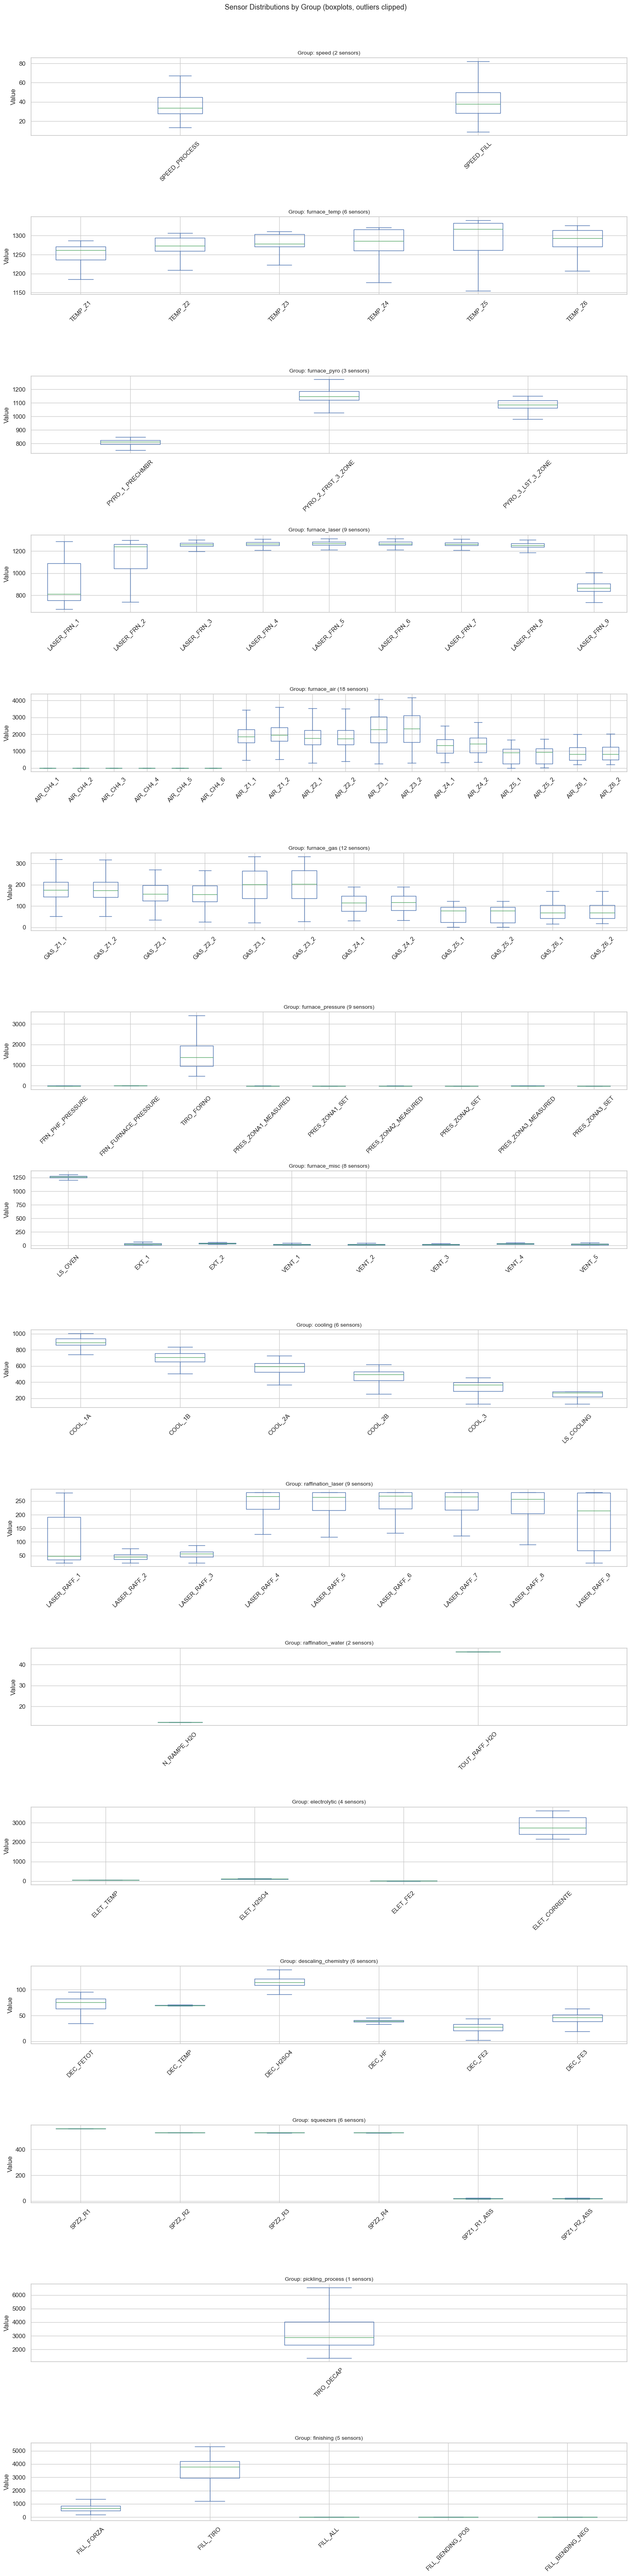

In [31]:
# ============================================================
# SECTION 4: Sensor Distributions
# ============================================================

fig, axes = plt.subplots(len(sensor_groups), 1, figsize=(16, len(sensor_groups) * 4))

for ax_idx, (group_name, group_cols) in enumerate(sensor_groups.items()):
    # Only plot columns that exist in the dataframe
    valid_cols = [c for c in group_cols if c in plc_df.columns]
    if not valid_cols:
        continue

    data = plc_df[valid_cols].copy()

    # Clip outliers at 1st-99th percentile for visibility
    for col in valid_cols:
        lo, hi = data[col].quantile(0.01), data[col].quantile(0.99)
        data[col] = data[col].clip(lo, hi)

    data.plot(kind='box', ax=axes[ax_idx], showfliers=False)
    axes[ax_idx].set_title(f'Group: {group_name} ({len(valid_cols)} sensors)', fontsize=10)
    axes[ax_idx].set_ylabel('Value')
    axes[ax_idx].tick_params(axis='x', rotation=45)

plt.suptitle('Sensor Distributions by Group (boxplots, outliers clipped)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# SECTION 4b: Investigate Suspicious Sensors
# ============================================================

suspicious = [
    'TIRO_FORNO',
    'LS_OVEN',
    'AIR_CH4_1', 'AIR_CH4_2', 'AIR_CH4_3',
    'AIR_CH4_4', 'AIR_CH4_5', 'AIR_CH4_6',
    'EXT_1', 'EXT_2',
    'VENT_1', 'VENT_2', 'VENT_3', 'VENT_4', 'VENT_5',
]

print("🔍 Suspicious Sensor Analysis:")
print(f"{'Sensor':<25} {'Unique':>7} {'Min':>10} {'Median':>10} {'Max':>10} {'% Zero':>8} {'Std':>10}")
print("-" * 85)

for col in suspicious:
    if col in plc_df.columns:
        s = plc_df[col].dropna()
        print(f"{col:<25} {s.nunique():>7} {s.min():>10.2f} {s.median():>10.2f} "
              f"{s.max():>10.2f} {(s==0).mean()*100:>7.1f}% {s.std():>10.2f}")

🔍 Suspicious Sensor Analysis:
Sensor                     Unique        Min     Median        Max   % Zero        Std
-------------------------------------------------------------------------------------
TIRO_FORNO                 231543     243.87    1372.36    4487.87     0.0%     746.93
LS_OVEN                    141047     675.01    1263.52    1400.54     0.0%      65.89
AIR_CH4_1                  101250    -155.81       1.29     193.36     0.0%       1.32
AIR_CH4_2                  122096    -209.25       1.35     218.59     0.0%       2.64
AIR_CH4_3                  126284    -243.83       1.34     406.52     0.0%       2.24
AIR_CH4_4                  120878     -18.87       1.39      11.74     0.0%       0.15
AIR_CH4_5                  172568      -0.37       1.39       3.91     0.0%       0.22
AIR_CH4_6                  158824    -237.55       1.37     236.70     0.0%       1.90
EXT_1                      263488       7.77      20.60      79.14     0.0%      17.24
EXT_2         

In [33]:
# ============================================================
# FINDING 3: Negative AIR_CH4 values
# ============================================================

air_ch4_cols = ['AIR_CH4_1', 'AIR_CH4_2', 'AIR_CH4_3',
                'AIR_CH4_4', 'AIR_CH4_5', 'AIR_CH4_6']

print("🔍 Negative value investigation — AIR_CH4 sensors:")
print(f"{'Sensor':<12} {'Neg Count':>10} {'Neg %':>8} {'Min':>10} {'Most common neg':>16}")
print("-" * 60)

for col in air_ch4_cols:
    s        = plc_df[col].dropna()
    neg_mask = s < 0
    neg_vals = s[neg_mask]
    print(f"{col:<12} {neg_mask.sum():>10,} {neg_mask.mean()*100:>7.2f}% "
          f"{s.min():>10.2f} {neg_vals.median():>16.2f}")

# Are negatives on the same rows across all AIR_CH4 sensors?
neg_masks = {col: plc_df[col] < 0 for col in air_ch4_cols}
all_neg   = neg_masks['AIR_CH4_1']
for col in air_ch4_cols[1:]:
    all_neg = all_neg & neg_masks[col]

print(f"\nRows where ALL AIR_CH4 sensors are negative : {all_neg.sum():,}")
print(f"Rows where ANY AIR_CH4 sensor is negative   : {sum(neg_masks[c].sum() for c in air_ch4_cols):,}")

# What coils do these belong to?
neg_coils = plc_df[all_neg][COIL_COL].nunique()
print(f"Coils affected                               : {neg_coils:,}")

🔍 Negative value investigation — AIR_CH4 sensors:
Sensor        Neg Count    Neg %        Min  Most common neg
------------------------------------------------------------
AIR_CH4_1            76    0.03%    -155.81            -9.68
AIR_CH4_2         1,110    0.37%    -209.25            -2.63
AIR_CH4_3         1,892    0.63%    -243.83            -2.89
AIR_CH4_4           569    0.19%     -18.87            -0.10
AIR_CH4_5           113    0.04%      -0.37            -0.08
AIR_CH4_6           209    0.07%    -237.55           -35.41

Rows where ALL AIR_CH4 sensors are negative : 0
Rows where ANY AIR_CH4 sensor is negative   : 3,969
Coils affected                               : 0


In [34]:
# ============================================================
# FINDING 3 — FINAL: AIR_CH4 negative values
# ============================================================

print("📋 Finding 3: AIR_CH4 Negative Values")
print(f"  Affected rows  : 3,969 across all 6 sensors (<0.63% each)")
print(f"  Root cause     : Sensor noise at burner shutdown boundary")
print(f"  Action         : Clip to 0 — np.maximum(col, 0)")

# Apply the fix
for col in air_ch4_cols:
    plc_df[col] = plc_df[col].clip(lower=0)

# Verify
still_neg = sum((plc_df[col] < 0).sum() for col in air_ch4_cols)
print(f"\n✅ After clipping — negative values remaining: {still_neg}")
print(f"   plc_df shape unchanged: {plc_df.shape}")


📋 Finding 3: AIR_CH4 Negative Values
  Affected rows  : 3,969 across all 6 sensors (<0.63% each)
  Root cause     : Sensor noise at burner shutdown boundary
  Action         : Clip to 0 — np.maximum(col, 0)

✅ After clipping — negative values remaining: 0
   plc_df shape unchanged: (299384, 113)


---
## 🔒 5. Stuck / Constant Sensors
Sensors with very few unique values are likely broken or irrelevant.

In [35]:
# ============================================================
# SECTION 5: Stuck / Constant Sensors
# ============================================================

unique_counts = plc_df[sensor_cols].nunique()
stuck         = unique_counts[unique_counts <= 1]
low_var       = unique_counts[(unique_counts > 1) & (unique_counts <= 10)]

print(f"{'Sensor':<25} {'Unique Values':>15} {'Min':>10} {'Max':>10} {'Std':>10}")
print("-" * 70)

print("\n🔴 Completely constant sensors (1 unique value):")
if len(stuck):
    for col in stuck.index:
        s = plc_df[col].dropna()
        print(f"  {col:<25} {s.nunique():>15} {s.min():>10.2f} {s.max():>10.2f} {s.std():>10.2f}")
else:
    print("  ✅ None found")

print("\n🟡 Almost constant sensors (2–10 unique values):")
if len(low_var):
    for col in low_var.index:
        s      = plc_df[col].dropna()
        counts = plc_df[col].value_counts().head(3).to_dict()
        print(f"  {col:<25} {s.nunique():>15} {s.min():>10.2f} {s.max():>10.2f}   top values: {counts}")
else:
    print("  ✅ None found")

Sensor                      Unique Values        Min        Max        Std
----------------------------------------------------------------------

🔴 Completely constant sensors (1 unique value):
  ✅ None found

🟡 Almost constant sensors (2–10 unique values):
  ✅ None found


---
## 📏 6. Sensor Behaviour Along Coil Length
How do sensor values evolve from start to end of a coil?

In [ ]:
if plc_df is not None and COIL_COL in plc_df.columns and POS_COL in plc_df.columns and 'sensor_cols' in dir():
    sample_coils = plc_df[COIL_COL].value_counts().head(5).index.tolist()
    plot_sensors = sensor_cols[:4]  # change to sensors of interest
    for coil in sample_coils[:3]:
        coil_data = plc_df[plc_df[COIL_COL] == coil].sort_values(POS_COL)
        fig, axes = plt.subplots(1, len(plot_sensors), figsize=(16, 3))
        if len(plot_sensors) == 1: axes = [axes]
        for ax, col in zip(axes, plot_sensors):
            ax.plot(coil_data[POS_COL], coil_data[col], linewidth=0.8, alpha=0.8)
            ax.set_title(col, fontsize=9)
            ax.set_xlabel('Position (m)')
        fig.suptitle(f'Coil {coil} — Sensor Profiles Along Length', fontsize=11)
        plt.tight_layout()
        plt.show()


---
## 🔗 7. Sensor Correlations
Identify redundant sensors — if two sensors have |r| ≥ 0.90, we may only need one.

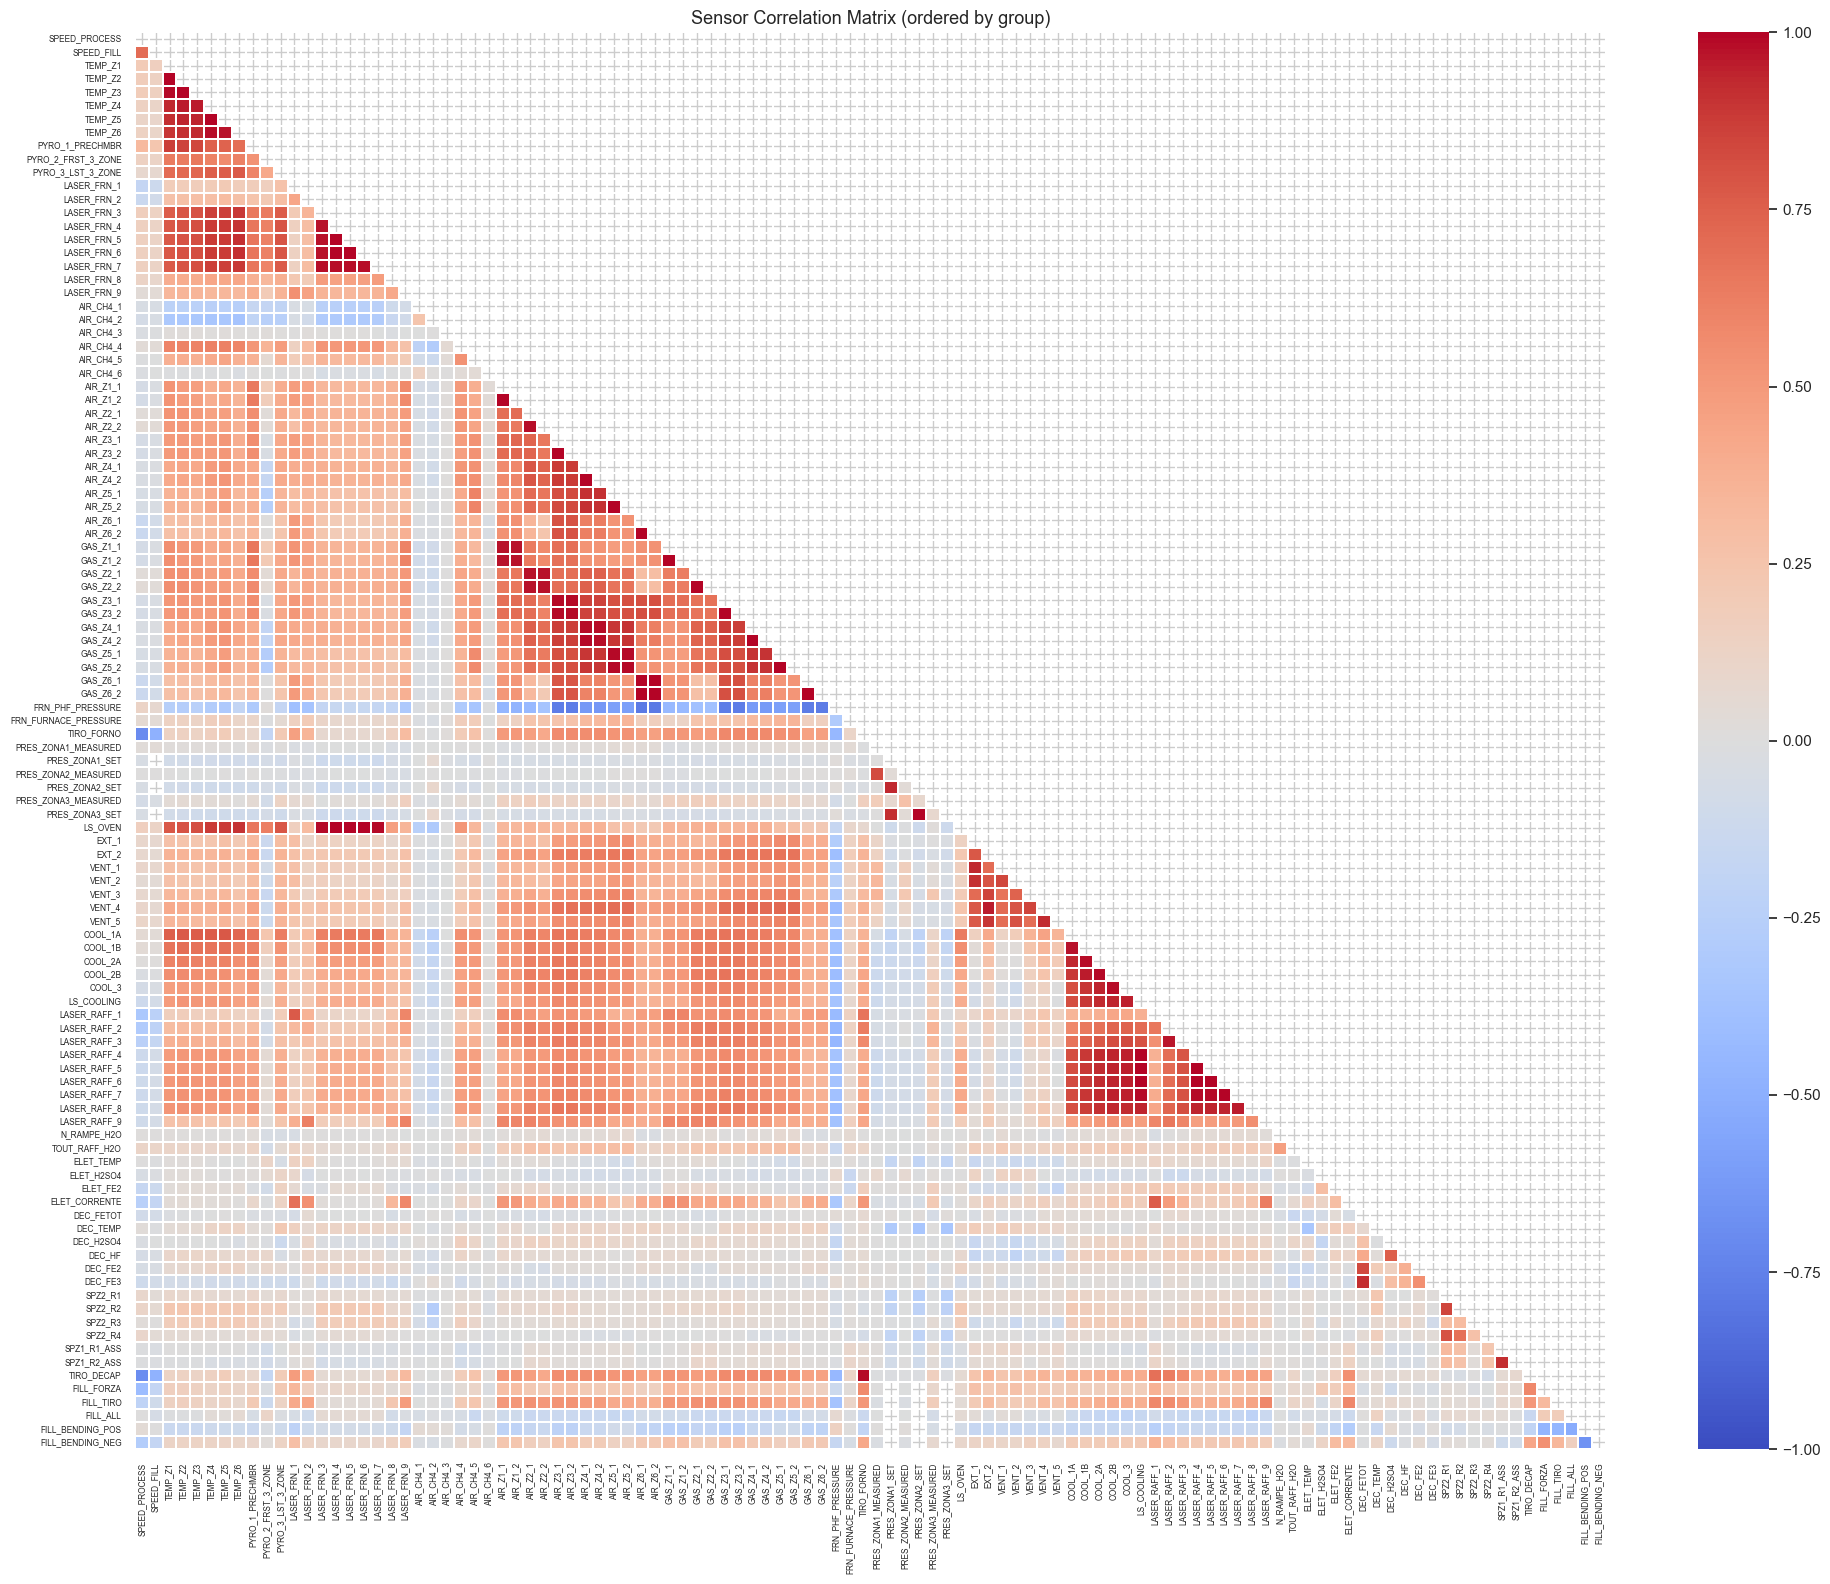


🔍 Highly correlated pairs (|r| ≥ 0.90):
Sensor A                  Sensor B                       r  Groups
---------------------------------------------------------------------------
  GAS_Z6_2                  GAS_Z6_1                     1.0  ← same group
  LASER_FRN_5               LASER_FRN_4                  1.0  ← same group
  GAS_Z3_2                  GAS_Z3_1                     1.0  ← same group
  AIR_Z6_2                  AIR_Z6_1                     1.0  ← same group
  AIR_Z5_2                  AIR_Z5_1                     1.0  ← same group
  AIR_Z4_2                  AIR_Z4_1                     1.0  ← same group
  AIR_Z3_2                  AIR_Z3_1                     1.0  ← same group
  GAS_Z5_2                  GAS_Z5_1                     1.0  ← same group
  LASER_FRN_6               LASER_FRN_5                  1.0  ← same group
  LASER_FRN_6               LASER_FRN_4                  1.0  ← same group
  GAS_Z1_2                  GAS_Z1_1                     1.0  ← sa

In [36]:
# ============================================================
# SECTION 7: Sensor Correlations
# ============================================================

# Sample for speed on large dataset
sample = plc_df[sensor_cols].sample(min(10_000, len(plc_df)), random_state=42)
corr   = sample.corr()

# Plot heatmap — sensors ordered by group
ordered_cols = [c for group in sensor_groups.values() for c in group if c in sensor_cols]
corr_ordered = corr.loc[ordered_cols, ordered_cols]
mask         = np.triu(np.ones_like(corr_ordered, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_ordered, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.2,
    xticklabels=True, yticklabels=True
)
ax.set_title('Sensor Correlation Matrix (ordered by group)', fontsize=13)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

# Print highly correlated pairs
print("\n🔍 Highly correlated pairs (|r| ≥ 0.90):")
print(f"{'Sensor A':<25} {'Sensor B':<25} {'r':>6}  {'Groups'}")
print("-" * 75)

high_corr = []
for i in range(len(corr_ordered.columns)):
    for j in range(i):
        r = corr_ordered.iloc[i, j]
        if abs(r) >= 0.90:
            col_a = corr_ordered.columns[i]
            col_b = corr_ordered.columns[j]
            high_corr.append({
                'Sensor A': col_a,
                'Sensor B': col_b,
                'r'       : round(r, 3),
                'Group A' : col_to_group.get(col_a, '?'),
                'Group B' : col_to_group.get(col_b, '?'),
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
for _, row in high_corr_df.iterrows():
    same = '← same group' if row['Group A'] == row['Group B'] else '← cross group!'
    print(f"  {row['Sensor A']:<25} {row['Sensor B']:<25} {row['r']:>6}  {same}")

print(f"\nTotal high-corr pairs: {len(high_corr_df)}")

In [37]:
# Print high correlation pairs only
print(f"\n🔍 Highly correlated pairs (|r| ≥ 0.90):")
print(f"{'Sensor A':<25} {'Sensor B':<25} {'r':>6}  {'Groups'}")
print("-" * 75)

for _, row in high_corr_df.iterrows():
    same = '← same group' if row['Group A'] == row['Group B'] else '← CROSS GROUP!'
    print(f"  {row['Sensor A']:<25} {row['Sensor B']:<25} {row['r']:>6}  {same}")

print(f"\nTotal high-corr pairs: {len(high_corr_df)}")

# Summary by group
print("\n📊 High-corr pairs by group:")
group_summary = high_corr_df.groupby('Group A').size().sort_values(ascending=False)
display(group_summary)



🔍 Highly correlated pairs (|r| ≥ 0.90):
Sensor A                  Sensor B                       r  Groups
---------------------------------------------------------------------------
  GAS_Z6_2                  GAS_Z6_1                     1.0  ← same group
  LASER_FRN_5               LASER_FRN_4                  1.0  ← same group
  GAS_Z3_2                  GAS_Z3_1                     1.0  ← same group
  AIR_Z6_2                  AIR_Z6_1                     1.0  ← same group
  AIR_Z5_2                  AIR_Z5_1                     1.0  ← same group
  AIR_Z4_2                  AIR_Z4_1                     1.0  ← same group
  AIR_Z3_2                  AIR_Z3_1                     1.0  ← same group
  GAS_Z5_2                  GAS_Z5_1                     1.0  ← same group
  LASER_FRN_6               LASER_FRN_5                  1.0  ← same group
  LASER_FRN_6               LASER_FRN_4                  1.0  ← same group
  GAS_Z1_2                  GAS_Z1_1                     1.0  ← sa

Group A
furnace_gas            34
raffination_laser      31
furnace_temp           14
furnace_laser          13
cooling                10
furnace_air            10
furnace_misc           10
furnace_pressure        3
descaling_chemistry     1
pickling_process        1
squeezers               1
dtype: int64

In [38]:
# ============================================================
# CHECK: Are _1 and _2 truly identical or subtly different?
# ============================================================

pairs_to_check = [
    ('AIR_Z1_1', 'AIR_Z1_2'),
    ('AIR_Z3_1', 'AIR_Z3_2'),
    ('GAS_Z1_1', 'GAS_Z1_2'),
    ('GAS_Z3_1', 'GAS_Z3_2'),
]

print(f"{'Pair':<30} {'r':>6}  {'Mean diff':>12}  {'Max diff':>12}  {'% identical':>12}")
print("-" * 80)

for col_a, col_b in pairs_to_check:
    both    = plc_df[[col_a, col_b]].dropna()
    r       = both.corr().iloc[0, 1]
    diff    = (both[col_a] - both[col_b]).abs()
    pct_identical = (diff == 0).mean() * 100

    print(f"{col_a+' vs '+col_b:<30} {r:>6.3f}  "
          f"{diff.mean():>12.4f}  {diff.max():>12.4f}  {pct_identical:>11.1f}%")

Pair                                r     Mean diff      Max diff   % identical
--------------------------------------------------------------------------------
AIR_Z1_1 vs AIR_Z1_2            0.997      112.4569      307.0087          0.0%
AIR_Z3_1 vs AIR_Z3_2            1.000       51.0539      134.1788          0.0%
GAS_Z1_1 vs GAS_Z1_2            1.000        0.9463        6.2084          0.0%
GAS_Z3_1 vs GAS_Z3_2            1.000        2.3353       29.0990          0.0%


In [40]:
# ============================================================
# FINDING 5 — FINAL: Correlations — noted for ML team
# ============================================================

print("📋 Finding 5: Sensor Correlations — handed to ML team")
print()
print("  128 high-corr pairs (|r| ≥ 0.90) identified.")
print("  Key patterns:")
print("  • AIR_ZN_1/2 and GAS_ZN_1/2 — paired sensors, NOT duplicates")
print("  • Furnace zones TEMP_Z1-Z6 — highly correlated, all kept")
print("  • Speed sensors couple across groups (LS_OVEN, LASER_FRN, LS_COOLING)")
print("  • TIRO_DECAP / TIRO_FORNO — different locations, both kept")
print()
print("  ✅ All 60 sensors passed to merge step unchanged.")
print("  ⏭️  ML team to decide on feature selection post-merge.")

📋 Finding 5: Sensor Correlations — handed to ML team

  128 high-corr pairs (|r| ≥ 0.90) identified.
  Key patterns:
  • AIR_ZN_1/2 and GAS_ZN_1/2 — paired sensors, NOT duplicates
  • Furnace zones TEMP_Z1-Z6 — highly correlated, all kept
  • Speed sensors couple across groups (LS_OVEN, LASER_FRN, LS_COOLING)
  • TIRO_DECAP / TIRO_FORNO — different locations, both kept

  ✅ All 60 sensors passed to merge step unchanged.
  ⏭️  ML team to decide on feature selection post-merge.


---
## ⚖️ 8. Process Stability — Within-Coil Variance
How much does each coil vary internally? Outlier coils may indicate production anomalies.

In [ ]:
if plc_df is not None and COIL_COL in plc_df.columns and 'sensor_cols' in dir():
    coil_std  = plc_df.groupby(COIL_COL)[sensor_cols].std()
    coil_mean = plc_df.groupby(COIL_COL)[sensor_cols].mean().abs()
    coil_cv   = coil_std.div(coil_mean)
    mean_cv_per_coil = coil_cv.mean(axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    mean_cv_per_coil.hist(bins=50, ax=axes[0], color='mediumseagreen', edgecolor='white')
    axes[0].set_title('Mean Within-Coil CV')
    axes[0].set_xlabel('CV (std / |mean|)')
    mean_cv_per_coil.nlargest(10).plot(kind='barh', ax=axes[1], color='tomato')
    axes[1].set_title('Top 10 Most Variable Coils')
    axes[1].set_xlabel('Mean CV')
    plt.tight_layout()
    plt.show()
    print(f'Median within-coil CV : {mean_cv_per_coil.median():.3f}')
    print(f'Max within-coil CV    : {mean_cv_per_coil.max():.3f}  (coil: {mean_cv_per_coil.idxmax()})')


---
## 🔗 9. Merge Readiness Check
Verify the PLC data is ready to join with the defect labels.

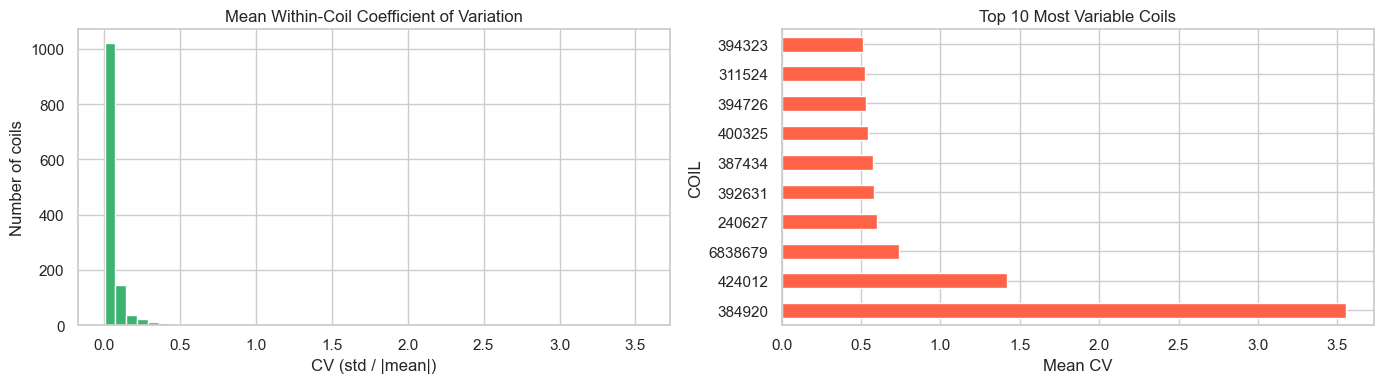

📊 Process Stability Summary:
  Median CV across all coils : 0.039
  Mean CV across all coils   : 0.065
  Max CV (most unstable)     : 3.552  → coil 384920
  Min CV (most stable)       : 0.002  → coil 400039

  Coils with CV > 1.0 (highly unstable) : 2
  Coils with CV > 0.5                   : 10

📡 Most variable sensors (highest mean CV across coils):


,Mean CV
PRES_ZONA2_MEASURED,0.457
PRES_ZONA1_MEASURED,0.415
FRN_PHF_PRESSURE,0.346
FRN_FURNACE_PRESSURE,0.285
SPEED_FILL,0.281
GAS_Z2_2,0.277
PRES_ZONA3_MEASURED,0.211
AIR_Z5_1,0.180
AIR_Z5_2,0.171
GAS_Z5_1,0.165


In [41]:
# ============================================================
# SECTION 8: Process Stability — Within-Coil Variance
# ============================================================

# Coefficient of variation per coil
coil_std  = plc_df.groupby(COIL_COL)[sensor_cols].std()
coil_mean = plc_df.groupby(COIL_COL)[sensor_cols].mean().abs()
coil_cv   = coil_std.div(coil_mean)

# Mean CV across all sensors per coil
mean_cv_per_coil = coil_cv.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mean_cv_per_coil.hist(bins=50, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Mean Within-Coil Coefficient of Variation')
axes[0].set_xlabel('CV (std / |mean|)')
axes[0].set_ylabel('Number of coils')

mean_cv_per_coil.nlargest(10).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 Most Variable Coils')
axes[1].set_xlabel('Mean CV')

plt.tight_layout()
plt.show()

print(f"📊 Process Stability Summary:")
print(f"  Median CV across all coils : {mean_cv_per_coil.median():.3f}")
print(f"  Mean CV across all coils   : {mean_cv_per_coil.mean():.3f}")
print(f"  Max CV (most unstable)     : {mean_cv_per_coil.max():.3f}  → coil {mean_cv_per_coil.idxmax()}")
print(f"  Min CV (most stable)       : {mean_cv_per_coil.min():.3f}  → coil {mean_cv_per_coil.idxmin()}")
print(f"\n  Coils with CV > 1.0 (highly unstable) : {(mean_cv_per_coil > 1.0).sum()}")
print(f"  Coils with CV > 0.5                   : {(mean_cv_per_coil > 0.5).sum()}")

# Which sensors are most variable across coils?
print(f"\n📡 Most variable sensors (highest mean CV across coils):")
sensor_mean_cv = coil_cv.mean(axis=0).sort_values(ascending=False)
display(sensor_mean_cv.head(10).to_frame(name='Mean CV').round(3))

In [42]:
# ============================================================
# FINDING 6: Process Stability
# ============================================================

# Flag unstable coils
UNSTABLE_CV_THRESHOLD = 1.0
unstable_coils = mean_cv_per_coil[mean_cv_per_coil > UNSTABLE_CV_THRESHOLD].index.tolist()

print("📋 Finding 6: Process Stability")
print(f"  Median CV                  : 0.039 — process is very stable overall")
print(f"  Unstable coils (CV > {UNSTABLE_CV_THRESHOLD}) : {unstable_coils}")
print(f"  Most variable sensors      : PRES_ZONA1/2/3_MEASURED, FRN pressures")
print(f"\n  ✅ No action needed — stable process, flag {len(unstable_coils)} outlier coils")

# Add to our flag set
UNSTABLE_COILS    = set(unstable_coils)
ALL_FLAGGED_COILS = SHORT_COILS | UNSTABLE_COILS

print(f"\n📊 All flagged coils so far:")
print(f"  Short coils (≤10 rows)   : {len(SHORT_COILS)}")
print(f"  Unstable coils (CV > 1.0): {len(UNSTABLE_COILS)}")
print(f"  Total unique flagged     : {len(ALL_FLAGGED_COILS)}")
print(f"  % of all coils           : {len(ALL_FLAGGED_COILS)/plc_df[COIL_COL].nunique()*100:.1f}%")


📋 Finding 6: Process Stability
  Median CV                  : 0.039 — process is very stable overall
  Unstable coils (CV > 1.0) : [384920, 424012]
  Most variable sensors      : PRES_ZONA1/2/3_MEASURED, FRN pressures

  ✅ No action needed — stable process, flag 2 outlier coils

📊 All flagged coils so far:
  Short coils (≤10 rows)   : 19
  Unstable coils (CV > 1.0): 2
  Total unique flagged     : 21
  % of all coils           : 1.7%


In [43]:
# ============================================================
# CHAPTER 4: MERGE PLC + DEFECT DATA
# ============================================================

# ── Step 1: Reload defect data ────────────────────────────────
defect_df = pd.read_csv('../data/cleaned/defect_cleaned.csv')

# Ensure correct types
defect_df['COIL']    = defect_df['COIL'].astype(int)
plc_df['COIL']       = plc_df['COIL'].astype(int)

defect_cols = ['DIF_TIPO_1', 'DIF_TIPO_2', 'DIF_TIPO_3',
               'DIF_TIPO_4', 'DIF_TIPO_5', 'DIF_TIPO_6']

print(f"✅ Defect data  : {defect_df.shape[0]:,} rows × {defect_df.shape[1]} cols")
print(f"✅ PLC data     : {plc_df.shape[0]:,} rows × {plc_df.shape[1]} cols")


✅ Defect data  : 617 rows × 14 cols
✅ PLC data     : 299,384 rows × 113 cols


In [44]:
# ── Step 2: Check coil overlap ────────────────────────────────
plc_coils    = set(plc_df['COIL'].unique())
defect_coils = set(defect_df['COIL'].unique())
overlap      = plc_coils & defect_coils

print(f"\n📊 Coil overlap:")
print(f"  PLC coils           : {len(plc_coils):,}")
print(f"  Defect coils        : {len(defect_coils):,}")
print(f"  In both             : {len(overlap):,}")
print(f"  Defect only (no PLC): {len(defect_coils - plc_coils):,}")
print(f"  PLC only (no defect): {len(plc_coils - defect_coils):,}")


📊 Coil overlap:
  PLC coils           : 1,261
  Defect coils        : 534
  In both             : 534
  Defect only (no PLC): 0
  PLC only (no defect): 727


In [46]:

# ── Step 3: Initialise label columns on PLC data ──────────────
for col in defect_cols:
    plc_df[col] = 0  # default = no defect

plc_df['HAS_DEFECT'] = 0

In [48]:
#Step 4: Merge via position range check ────────────────────
# For each defect segment, flag all PLC rows where:
#   COIL matches AND MT_FROM <= MT <= MT_TO

print(f"\n⏳ Merging {defect_df.shape[0]:,} defect segments onto {plc_df.shape[0]:,} PLC rows...")

matched_segments = 0

for _, defect_row in defect_df.iterrows():
    coil    = defect_row['COIL']
    mt_from = defect_row['MT_FROM']
    mt_to   = defect_row['MT_TO']

    # Find matching PLC rows
    mask = (
        (plc_df['COIL'] == coil) &
        (plc_df['MT']   >= mt_from) &
        (plc_df['MT']   <= mt_to)
    )

    if mask.sum() > 0:
        matched_segments += 1
        for col in defect_cols:
            if defect_row[col] == 1 or defect_row[col] == '1':
                plc_df.loc[mask, col] = 1
        plc_df.loc[mask, 'HAS_DEFECT'] = 1

print(f"✅ Done!")
print(f"  Defect segments matched : {matched_segments:,} / {defect_df.shape[0]:,}")
print(f"  Unmatched segments      : {defect_df.shape[0] - matched_segments:,}")



⏳ Merging 617 defect segments onto 299,384 PLC rows...
✅ Done!
  Defect segments matched : 614 / 617
  Unmatched segments      : 3


In [49]:
# ── Investigate 3 unmatched segments ─────────────────────────
print("🔍 Unmatched defect segments:")
print("-" * 60)

for _, defect_row in defect_df.iterrows():
    coil    = defect_row['COIL']
    mt_from = defect_row['MT_FROM']
    mt_to   = defect_row['MT_TO']

    mask = (
        (plc_df['COIL'] == coil) &
        (plc_df['MT']   >= mt_from) &
        (plc_df['MT']   <= mt_to)
    )

    if mask.sum() == 0:
        # Check if coil exists in PLC at all
        coil_exists = (plc_df['COIL'] == coil).sum()
        if coil_exists > 0:
            # Coil exists but position not found
            coil_mt_range = plc_df[plc_df['COIL'] == coil]['MT'].agg(['min', 'max'])
            print(f"  COIL {coil} | Defect: {mt_from}m → {mt_to}m")
            print(f"  PLC MT range: {coil_mt_range['min']}m → {coil_mt_range['max']}m")
            print(f"  ⚠️  Position out of PLC range")
        else:
            print(f"  COIL {coil} | Defect: {mt_from}m → {mt_to}m")
            print(f"  ❌ Coil not found in PLC data at all")
        print()

# Also print the full merge summary now
print(f"\n📊 Merged dataset summary:")
print(f"  Total PLC rows          : {len(plc_df):,}")
print(f"  Rows with any defect    : {plc_df['HAS_DEFECT'].sum():,} ({plc_df['HAS_DEFECT'].mean()*100:.1f}%)")
print(f"  Rows without defect     : {(plc_df['HAS_DEFECT']==0).sum():,} ({(plc_df['HAS_DEFECT']==0).mean()*100:.1f}%)")
print(f"\n  Defect type breakdown:")
for col in defect_cols:
    n = plc_df[col].sum()
    print(f"    {col} : {n:,} rows ({n/len(plc_df)*100:.1f}%)")

🔍 Unmatched defect segments:
------------------------------------------------------------
  COIL 389528 | Defect: 1400.0m → 1539.0m
  PLC MT range: 0.0m → 945.0m
  ⚠️  Position out of PLC range

  COIL 419215 | Defect: 60.0m → 60.0m
  PLC MT range: 49.0m → 917.0m
  ⚠️  Position out of PLC range

  COIL 422528 | Defect: 305.0m → 306.0m
  PLC MT range: 0.0m → 2170.0m
  ⚠️  Position out of PLC range


📊 Merged dataset summary:
  Total PLC rows          : 299,384
  Rows with any defect    : 106,739 (35.7%)
  Rows without defect     : 192,645 (64.3%)

  Defect type breakdown:
    DIF_TIPO_1 : 6,827 rows (2.3%)
    DIF_TIPO_2 : 10,636 rows (3.6%)
    DIF_TIPO_3 : 87,215 rows (29.1%)
    DIF_TIPO_4 : 52,214 rows (17.4%)
    DIF_TIPO_5 : 7,496 rows (2.5%)
    DIF_TIPO_6 : 7,246 rows (2.4%)


In [50]:
# ============================================================
# UNMATCHED SEGMENTS — EXPLANATION
# ============================================================

display(Markdown("""
### 🔍 3 Unmatched Segments — All Explainable

| Coil | Defect Range | PLC Range | Root Cause |
|------|-------------|-----------|------------|
| `389528` | 1,400–1,539m | 0–945m | PLC recording stopped early — tail-out effect |
| `419215` | 60m → 60m | 49–917m | Zero-length segment — flagged in Chapter 2 |
| `422528` | 305–306m | 0–2,170m | 1m defect falls between two 7m PLC readings — too narrow to catch |

### 💡 Why This Happens

**COIL 389528 — Tail-out:**
The defect was recorded at 1,400m but the PLC only captured up to 945m.
The strip had already exited the sensor zone before the coil finished winding.
This is the same tail-out effect we found in Finding 2.

**COIL 419215 — Zero-length segment:**
The defect start and end are both at 60m — a segment of 0m length.
This was already flagged in Chapter 2 as a data quality issue.
No PLC row can match a point that has no range.

**COIL 422528 — Too narrow for 7m resolution:**
The defect is only 1m wide (305m → 306m) but PLC readings are spaced ~7m apart.
The defect falls in the gap between two consecutive readings and is invisible
at this resolution. This is a fundamental limitation of the PLC sampling rate.

### ✅ Action
These 3 segments (0.5% of all defects) are accepted as unresolvable data gaps.
No action needed — document and move on.
"""))


### 🔍 3 Unmatched Segments — All Explainable

| Coil | Defect Range | PLC Range | Root Cause |
|------|-------------|-----------|------------|
| `389528` | 1,400–1,539m | 0–945m | PLC recording stopped early — tail-out effect |
| `419215` | 60m → 60m | 49–917m | Zero-length segment — flagged in Chapter 2 |
| `422528` | 305–306m | 0–2,170m | 1m defect falls between two 7m PLC readings — too narrow to catch |

### 💡 Why This Happens

**COIL 389528 — Tail-out:**
The defect was recorded at 1,400m but the PLC only captured up to 945m.
The strip had already exited the sensor zone before the coil finished winding.
This is the same tail-out effect we found in Finding 2.

**COIL 419215 — Zero-length segment:**
The defect start and end are both at 60m — a segment of 0m length.
This was already flagged in Chapter 2 as a data quality issue.
No PLC row can match a point that has no range.

**COIL 422528 — Too narrow for 7m resolution:**
The defect is only 1m wide (305m → 306m) but PLC readings are spaced ~7m apart.
The defect falls in the gap between two consecutive readings and is invisible
at this resolution. This is a fundamental limitation of the PLC sampling rate.

### ✅ Action
These 3 segments (0.5% of all defects) are accepted as unresolvable data gaps.
No action needed — document and move on.


In [51]:
# ============================================================
# STEP 6: Save merged dataset & final checks
# ============================================================

# Remove flagged coils before saving
merged_clean = plc_df[~plc_df['COIL'].isin(ALL_FLAGGED_COILS)].copy()

print(f"📊 Final dataset (flagged coils removed):")
print(f"  Before removing flagged : {len(plc_df):,} rows")
print(f"  After removing flagged  : {len(merged_clean):,} rows")
print(f"  Coils removed           : {len(ALL_FLAGGED_COILS)}")
print(f"  Defective rows          : {merged_clean['HAS_DEFECT'].sum():,} ({merged_clean['HAS_DEFECT'].mean()*100:.1f}%)")
print(f"  Clean rows              : {(merged_clean['HAS_DEFECT']==0).sum():,} ({(merged_clean['HAS_DEFECT']==0).mean()*100:.1f}%)")
print(f"  Final shape             : {merged_clean.shape}")

# Save
OUTPUT_PATH = '../data/cleaned/plc_defect_merged.csv'
merged_clean.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Saved to: {OUTPUT_PATH}")

📊 Final dataset (flagged coils removed):
  Before removing flagged : 299,384 rows
  After removing flagged  : 298,851 rows
  Coils removed           : 21
  Defective rows          : 106,526 (35.6%)
  Clean rows              : 192,325 (64.4%)
  Final shape             : (298851, 120)

✅ Saved to: ../data/cleaned/plc_defect_merged.csv


In [1]:
display(Markdown("""
# ❓ Questions for Domain Expert (SME)

## 🏭 Defect Data (Chapter 2)

- [ ] **What do the 6 defect types mean physically?**
      (Tipo 1–6 — what does each one look like on the steel strip?)
- [ ] **Why is Tipo 3 so dominant?**
      (Appears in 80% of all defect segments — is this expected?)
- [ ] **What do whole-coil defect segments represent?**
      (74% of segments cover >80% of coil length — are these rejected coils?)
- [ ] **Should whole-coil and localised defects be modelled separately?**
- [ ] **Do defect combinations matter?**
      (e.g. Tipo 2+3 together vs Tipo 3 alone — different severity?)

## 🏭 PLC Sensors (Chapter 3)

- [ ] **What do AIR_ZN_1 vs AIR_ZN_2 physically represent?**
      (Left/right burner? Top/bottom measurement?)
- [ ] **What units are TIRO_FORNO and TIRO_DECAP?**
      (Tension in N? kN?)
- [ ] **What is FILL_ALL exactly?**
      (Alignment measurement or a combined flag?)
- [ ] **Are short coils (≤10 rows) test runs or production rejects?**
      (19 coils flagged — should they be excluded from ML?)
- [ ] **Are coils 384920 and 424012 known production incidents?**
      (Flagged as highly unstable — CV > 1.0)
- [ ] **Under what conditions do LASER_RAFF sensors go inactive?**
      (5.26% missing — is this always tail-out or other reasons?)
- [ ] **Are all 9 finishing stands always active?**
      (FILL_* sensors missing 9.51% — only for certain coil types?)

## 🔗 Merge & Coverage (Chapter 4)

- [ ] **Why does COIL 389528 PLC data stop at 945m?**
      (Defect recorded up to 1,539m but PLC only covers 945m)
- [ ] **Is 1m defect resolution meaningful?**
      (COIL 422528 has a 1m defect — too narrow for 7m PLC resolution)

## 🤖 ML Strategy (Chapter 5)

- [ ] **Should we predict each defect type separately or combined?**
      (Multi-label vs 6 binary classifiers vs single HAS_DEFECT)
- [ ] **What is the cost of a false negative vs false positive?**
      (Missing a defect vs flagging a clean coil — which is worse?)
- [ ] **Is there a minimum defect length that matters?**
      (Very short defects may not be worth predicting)
"""))

NameError: name 'Markdown' is not defined

In [56]:
# ============================================================
# CHAPTER 5 SUMMARY — Preprocessing Checklist
# ============================================================

display(Markdown("""
# ⚙️ Chapter 5: Preprocessing Summary

## ✅ to be completed

- [ ] **Step 1 — Removed flagged coils** (21 coils, 1.7%)
- [ ] **Step 2 — Separated whole-coil vs localised defects** (decision point flagged for ML team)
- [ ] **Step 3 — Train/test split by COIL** (80/20, random_state=42)
- [ ] **Step 4 — Defined feature & label columns**
- [ ] **Step 5 — Handled missing values** (kept for XGBoost, imputed for linear models)
- [ ] **Step 6 — Feature scaling** (StandardScaler, fit on train only)
- [ ] **Step 7 — Class imbalance noted** (scale_pos_weight calculated for XGBoost)
- [ ] **Step 8 — All splits saved to ../data/cleaned/**

## ⏭️ Next Steps for ML Team

- [ ] Choose model type (XGBoost recommended as first baseline)
- [ ] Decide on whole-coil vs localised defect strategy
- [ ] Use `scale_pos_weight` or SMOTE for class imbalance
- [ ] Evaluate with PR-AUC not accuracy
- [ ] Feature importance analysis to reduce 60 sensors
- [ ] Consider rolling window features along coil length
"""))


# ⚙️ Chapter 5: Preprocessing Summary

## ✅ to be completed

- [ ] **Step 1 — Removed flagged coils** (21 coils, 1.7%)
- [ ] **Step 2 — Separated whole-coil vs localised defects** (decision point flagged for ML team)
- [ ] **Step 3 — Train/test split by COIL** (80/20, random_state=42)
- [ ] **Step 4 — Defined feature & label columns**
- [ ] **Step 5 — Handled missing values** (kept for XGBoost, imputed for linear models)
- [ ] **Step 6 — Feature scaling** (StandardScaler, fit on train only)
- [ ] **Step 7 — Class imbalance noted** (scale_pos_weight calculated for XGBoost)
- [ ] **Step 8 — All splits saved to ../data/cleaned/**

## ⏭️ Next Steps for ML Team

- [ ] Choose model type (XGBoost recommended as first baseline)
- [ ] Decide on whole-coil vs localised defect strategy
- [ ] Use `scale_pos_weight` or SMOTE for class imbalance
- [ ] Evaluate with PR-AUC not accuracy
- [ ] Feature importance analysis to reduce 60 sensors
- [ ] Consider rolling window features along coil length
